In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("data.csv")
data.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
print("Shape :",data.shape)

Shape : (11914, 16)


In [4]:
print("Columns :\n" , data.columns)

Columns :
 Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')


In [5]:
print("Info :",data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [6]:
print("Missing Values :\n" , data.isnull().sum())

Missing Values :
 Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [7]:
data.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [8]:
print("Number of duplicated rows in our dataset : ",data.duplicated().sum())

Number of duplicated rows in our dataset :  715


In [9]:
#removing duplicates
data = data.drop_duplicates()
print("Number of duplicate rows after dropping duplicated rows : ",data.duplicated().sum())
print("Number of rows after drop duplicate rows :", data.shape)

Number of duplicate rows after dropping duplicated rows :  0
Number of rows after drop duplicate rows : (11199, 16)


In [10]:
#droping Market Category colum because has so many null values and does not really help that much in the price predictions anyways.
data = data.drop("Market Category",axis = 1)
data.isnull().sum()

Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

In [11]:
# filling null values 
data["Engine Fuel Type"].fillna(data["Engine Fuel Type"].mode()[0],inplace = True )
data["Engine HP"].fillna(data["Engine HP"].median(),inplace = True )
data["Engine Cylinders"].fillna(data["Engine Cylinders"].median(),inplace = True )
data["Number of Doors"].fillna(data["Number of Doors"].median(),inplace = True )

print("Now Check Number of null values : ", data.isnull().sum())


Now Check Number of null values :  Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64


C:\Users\hetal\AppData\Local\Temp\ipykernel_352\2364348078.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Engine Fuel Type"].fillna(data["Engine Fuel Type"].mode()[0],inplace = True )
C:\Users\hetal\AppData\Local\Temp\ipykernel_352\2364348078.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

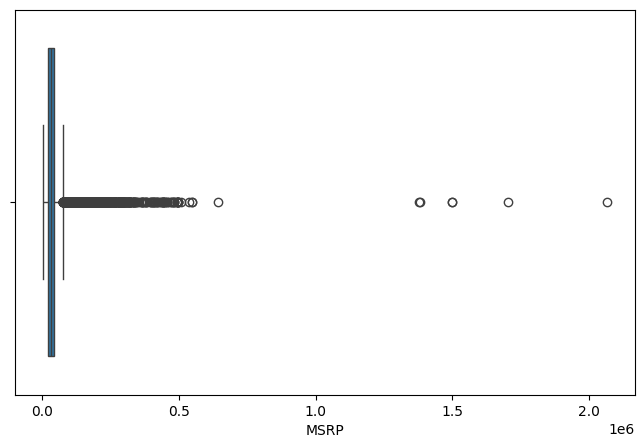

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["MSRP"])
plt.show()

In [16]:
q1 = data["MSRP"].quantile(0.25)
q3 = data["MSRP"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data = data[(data["MSRP"] >= lower_bound) & (data["MSRP"] <= upper_bound)]

print("Shape of the data after removing extreme outliers :", data.shape)


Shape of the data after removing extreme outliers : (10068, 15)


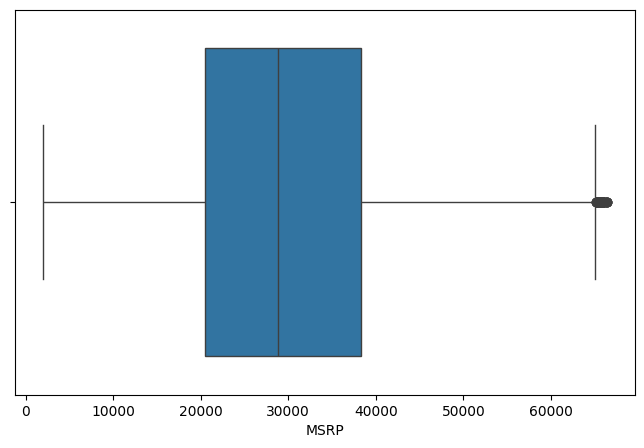

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["MSRP"])
plt.show()

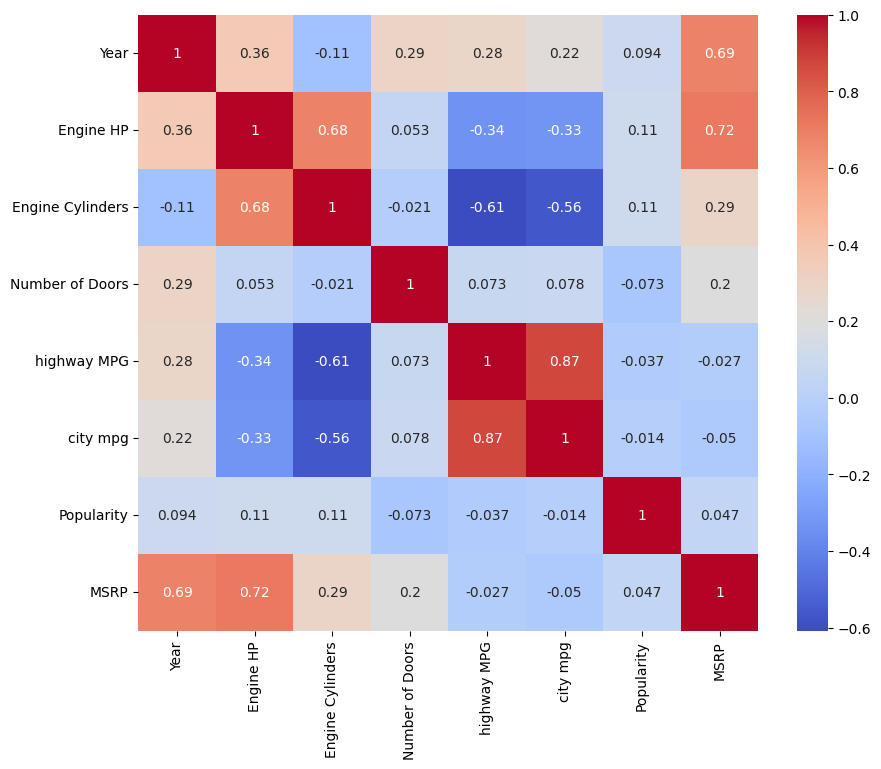

In [18]:
numeric_data = data.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(),annot=True,cmap="coolwarm")
plt.show()

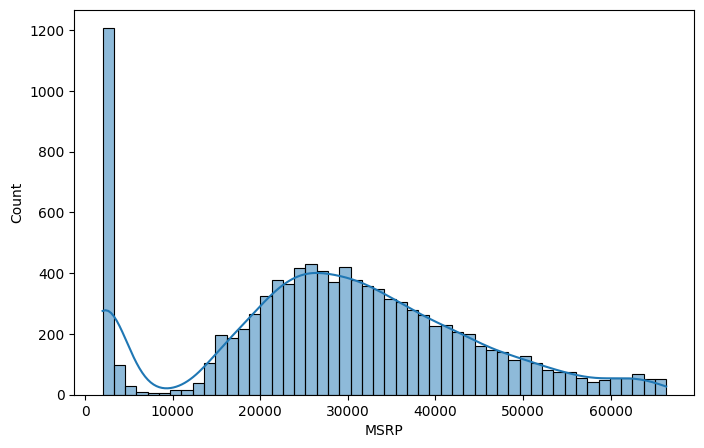

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data["MSRP"],bins=50,kde=True)
plt.show()

### Key Insights from Analysis

-> Engine HP and Year have strong positive correlation with MSRP.

-> Cars with higher horsepower tend to be more expensive.

-> Newer cars generally have higher MSRP.

-> MSRP distribution is right-skewed.

-> Most cars fall in the 15,000–40,000 price range.

-> Extreme outliers were removed using IQR method.

-> Missing values were handled using median (numerical) and mode (categorical).

-> Duplicate rows were removed to improve data quality.